In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))#

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session#

/kaggle/input/MLSP2023-volunteers-part2/colab_test_candidate_multistep.csv
/kaggle/input/MLSP2023-volunteers-part2/colab_test.csv
/kaggle/input/MLSP2023-volunteers-part2/colab_train.csv
/kaggle/input/MLSP2023-volunteers-part2/sample_submission_collaboration_multistep.csv
/kaggle/input/MLSP2023-volunteers-part2/colab_train_edge_list.csv


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings
pd.options.display.max_columns=None

In [3]:
train = pd.read_csv('/kaggle/input/MLSP2023-volunteers-part2/colab_train.csv')
train.head()

,user_id,is_organizer,task_id,task_location,task_district,user_location,longitude,latitude,task_start_time,task_end_time,task_start_date,task_end_date
0,60943,1,211219,Yuanling(Street),Futian(District),Futian(District)-Yuanling(Street)-Hualin(Commu...,118.746610,32.061234,2020/9/26 1:00,2020/9/26 6:55,2020/9/26,2020/9/26
1,99313,0,211095,Fucheng(Street),Longhua(District),Longhua(District)-Fucheng(Street)-Dashuikeng(C...,114.006699,22.730143,2020/9/26 10:30,2020/9/26 17:30,2020/9/26,2020/9/26
2,65362,0,211089,Meilin(Street),Futian(District),Futian(District)-Meilin(Street)-Maling(Community),114.066054,22.569335,2020/9/26 16:20,2020/9/26 18:00,2020/9/26,2020/9/26
3,66000,0,211089,Meilin(Street),Futian(District),Futian(District)-Meilin(Street)-Maling(Community),114.066054,22.569335,2020/9/26 16:20,2020/9/26 18:00,2020/9/26,2020/9/26
4,65362,0,211085,Meilin(Street),Futian(District),Futian(District)-Meilin(Street)-Maling(Community),114.066095,22.569256,2020/9/26 14:00,2020/9/26 16:00,2020/9/26,2020/9/26


In [4]:
test = pd.read_csv('/kaggle/input/MLSP2023-volunteers-part2/colab_test.csv')
test.head()

,Unnamed: 0,user_id,is_organizer,task_id,task_location,task_district,user_location,longitude,latitude,task_start_time,task_end_time,task_start_date,task_end_date
0,0,5093,0,211089,Meilin(Street),Futian(District),Futian(District)-Meilin(Street)-Maling(Community),114.066054,22.569335,2020-09-26 16:20:00,2020-09-26 18:00:00,2020-09-26,2020-09-26
1,1,64661,0,211089,Meilin(Street),Futian(District),Futian(District)-Meilin(Street)-Maling(Community),114.066054,22.569335,2020-09-26 16:20:00,2020-09-26 18:00:00,2020-09-26,2020-09-26
2,2,65955,0,211089,Meilin(Street),Futian(District),Futian(District)-Meilin(Street)-Maling(Community),114.066054,22.569335,2020-09-26 16:20:00,2020-09-26 18:00:00,2020-09-26,2020-09-26
3,3,67310,0,211089,Meilin(Street),Futian(District),Futian(District)-Meilin(Street)-Maling(Community),114.066054,22.569335,2020-09-26 16:20:00,2020-09-26 18:00:00,2020-09-26,2020-09-26
4,4,5093,0,211085,Meilin(Street),Futian(District),Futian(District)-Meilin(Street)-Maling(Community),114.066095,22.569256,2020-09-26 14:00:00,2020-09-26 16:00:00,2020-09-26,2020-09-26


In [5]:
combined = pd.concat([train,test])
combined.head()

,user_id,is_organizer,task_id,task_location,task_district,user_location,longitude,latitude,task_start_time,task_end_time,task_start_date,task_end_date,Unnamed: 0
0,60943,1,211219,Yuanling(Street),Futian(District),Futian(District)-Yuanling(Street)-Hualin(Commu...,118.746610,32.061234,2020/9/26 1:00,2020/9/26 6:55,2020/9/26,2020/9/26,NaN
1,99313,0,211095,Fucheng(Street),Longhua(District),Longhua(District)-Fucheng(Street)-Dashuikeng(C...,114.006699,22.730143,2020/9/26 10:30,2020/9/26 17:30,2020/9/26,2020/9/26,NaN
2,65362,0,211089,Meilin(Street),Futian(District),Futian(District)-Meilin(Street)-Maling(Community),114.066054,22.569335,2020/9/26 16:20,2020/9/26 18:00,2020/9/26,2020/9/26,NaN
3,66000,0,211089,Meilin(Street),Futian(District),Futian(District)-Meilin(Street)-Maling(Community),114.066054,22.569335,2020/9/26 16:20,2020/9/26 18:00,2020/9/26,2020/9/26,NaN
4,65362,0,211085,Meilin(Street),Futian(District),Futian(District)-Meilin(Street)-Maling(Community),114.066095,22.569256,2020/9/26 14:00,2020/9/26 16:00,2020/9/26,2020/9/26,NaN


In [6]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 709445 entries, 0 to 377060
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   user_id          709445 non-null  int64  
 1   is_organizer     709445 non-null  int64  
 2   task_id          709445 non-null  int64  
 3   task_location    709445 non-null  object 
 4   task_district    709445 non-null  object 
 5   user_location    709445 non-null  object 
 6   longitude        709445 non-null  float64
 7   latitude         709445 non-null  float64
 8   task_start_time  709445 non-null  object 
 9   task_end_time    709445 non-null  object 
 10  task_start_date  709445 non-null  object 
 11  task_end_date    709445 non-null  object 
 12  Unnamed: 0       377061 non-null  float64
dtypes: float64(3), int64(3), object(7)
memory usage: 75.8+ MB


In [7]:
combined.dtypes

user_id              int64
is_organizer         int64
task_id              int64
task_location       object
task_district       object
user_location       object
longitude          float64
latitude           float64
task_start_time     object
task_end_time       object
task_start_date     object
task_end_date       object
Unnamed: 0         float64
dtype: object

In [8]:
combined.isnull().sum()/len(combined)*100

user_id             0.000000
is_organizer        0.000000
task_id             0.000000
task_location       0.000000
task_district       0.000000
user_location       0.000000
longitude           0.000000
latitude            0.000000
task_start_time     0.000000
task_end_time       0.000000
task_start_date     0.000000
task_end_date       0.000000
Unnamed: 0         46.851271
dtype: float64

In [9]:
combined.shape

(709445, 13)

In [10]:
combined.skew()

/tmp/ipykernel_20/3158812268.py:1: FutureWarning: The default value of numeric_only in DataFrame.skew is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  combined.skew()


user_id         2.442789e-02
is_organizer    8.049168e-01
task_id        -5.863706e-03
longitude       9.889534e+01
latitude        1.242261e+02
Unnamed: 0     -7.328352e-16
dtype: float64

In [11]:
combined.kurt()

/tmp/ipykernel_20/292944781.py:1: FutureWarning: The default value of numeric_only in DataFrame.kurt is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  combined.kurt()


user_id            -1.032822
is_organizer       -1.352113
task_id            -1.203630
longitude       16191.548179
latitude        20399.808337
Unnamed: 0         -1.200000
dtype: float64

<Axes: >

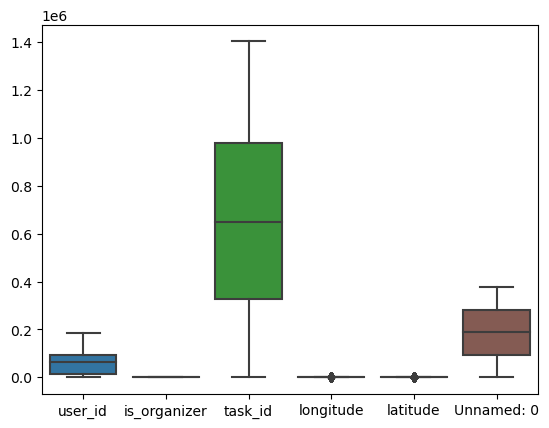

In [12]:
sns.boxplot(combined)

<Axes: >

/opt/conda/lib/python3.10/site-packages/IPython/core/events.py:89: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/opt/conda/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


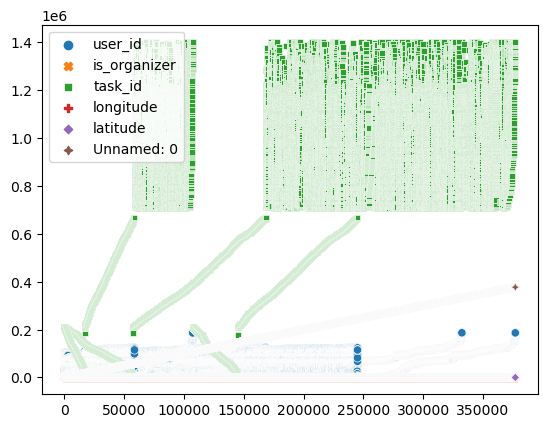

In [13]:
sns.scatterplot(combined)

<Axes: >

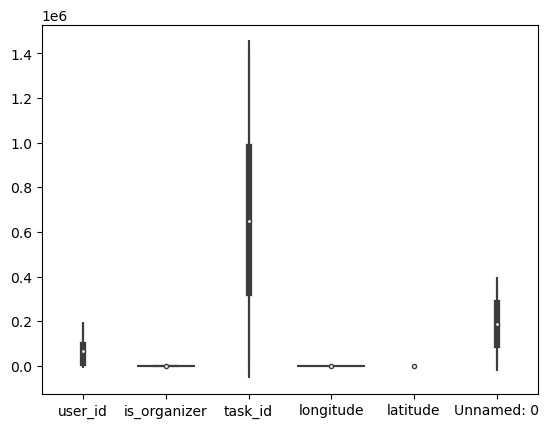

In [14]:
sns.violinplot(combined)

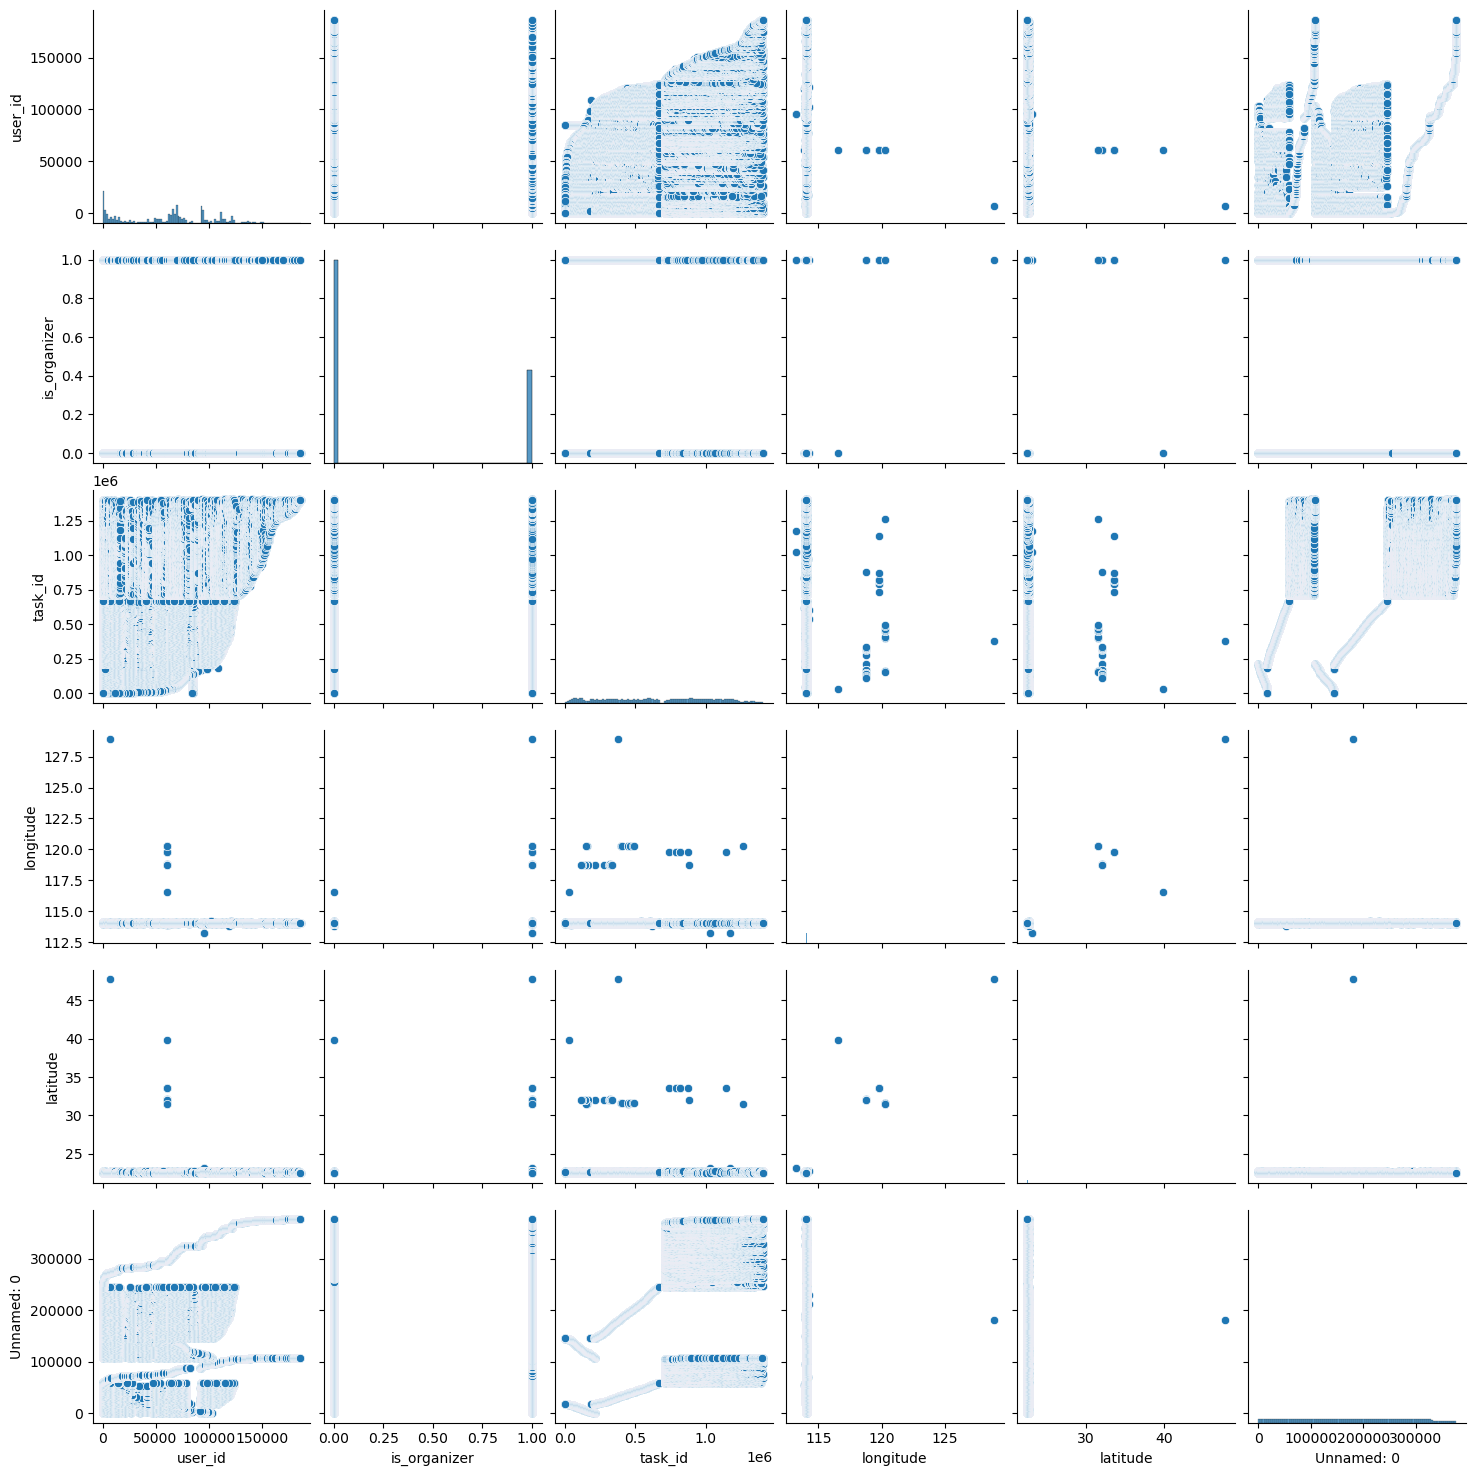

In [15]:
sns.pairplot(combined)

<Axes: >

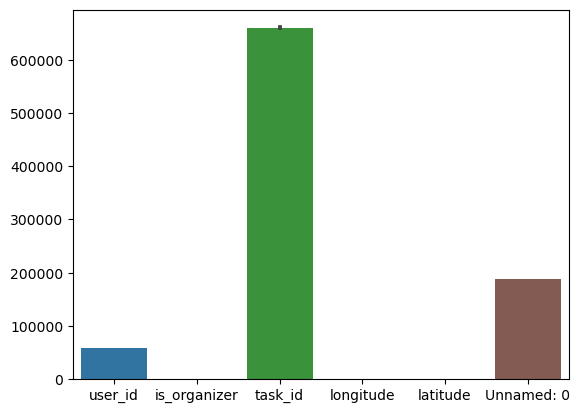

In [16]:
sns.barplot(combined)

/tmp/ipykernel_20/1658940522.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(combined.corr(),annot=True)


<Axes: >

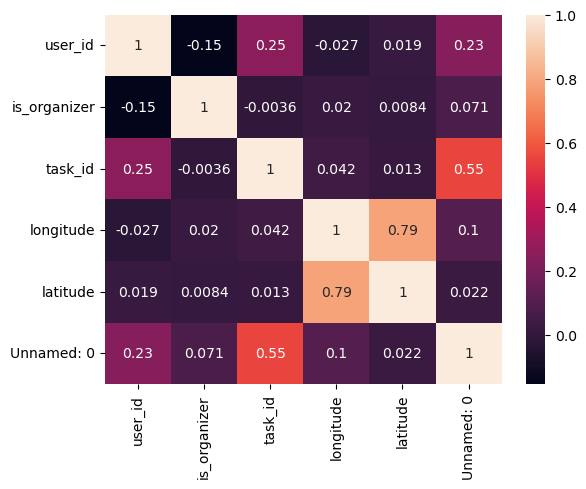

In [17]:
sns.heatmap(combined.corr(),annot=True)

In [18]:
cat_cols = combined.select_dtypes(include='object')

In [19]:
for i in cat_cols:
    print(i)
    print(combined[i].value_counts())
    print(''*50)

task_location
Meilin(Street)         153693
Nanyuan(Street)        134971
Huafu(Street)          107870
Shatou(Street)          85696
Xiangmihu(Street)       64122
Fubao(Street)           44843
Lianhua(Street)         41389
Futian(Street)          24884
Yuanling(Street)        23165
Minzhi(Street)           9616
Huaqiangbei(Street)      7442
Dalang(Street)           3439
Fucheng(Street)          3419
Guanlan(Street)          2234
Guanhu(Street)           1609
Longhua(Street)          1053
Name: task_location, dtype: int64

task_district
Futian(District)     688075
Longhua(District)     21370
Name: task_district, dtype: int64

user_location
Nan                                                        63664
Futian(District)-Shatou(Street)-Jinbi(Community)           27824
Futian(District)-Meilin(Street)-Shangmei(Community)        18754
Shangmei(Community)                                        14486
Futian(District)-Nanyuan(Street)-Chiwei(Community)         14093
                           

In [20]:
num_cols = combined.select_dtypes(include='number')

In [21]:
for i in num_cols:
    print(i)
    print(combined[i].value_counts())
    print('_'*50)

user_id
960       9578
67488     6126
70445     5756
93293     5476
64754     4836
          ... 
184526       1
143445       1
169110       1
168641       1
105730       1
Name: user_id, Length: 2675, dtype: int64
__________________________________________________
is_organizer
0    487160
1    222285
Name: is_organizer, dtype: int64
__________________________________________________
task_id
602922     67
602920     63
891852     62
864634     62
618877     62
           ..
798643      1
798647      1
798649      1
798653      1
1330813     1
Name: task_id, Length: 260066, dtype: int64
__________________________________________________
longitude
114.086525    30881
114.054276    17859
114.023960    14261
114.056040    13769
114.095900    12068
              ...  
114.033223        1
114.100646        1
114.100603        1
114.100606        1
114.049225        1
Name: longitude, Length: 8027, dtype: int64
__________________________________________________
latitude
22.532925    30881
22.

In [22]:
combined['user_id']=combined['user_id'].map({'Good':2,'Standard':1,'Poor':0})

/tmp/ipykernel_20/401063577.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(combined.corr(),annot=True,cmap='afmhot_r')


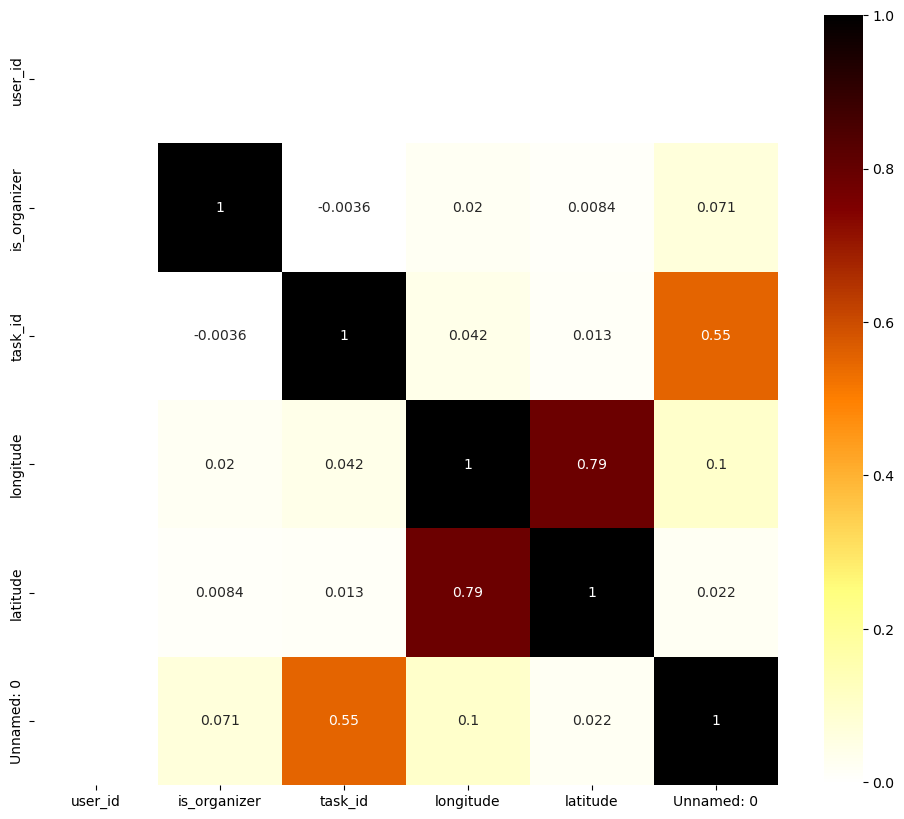

In [23]:
plt.figure(figsize=(12,10))
sns.heatmap(combined.corr(),annot=True,cmap='afmhot_r')
plt.show()

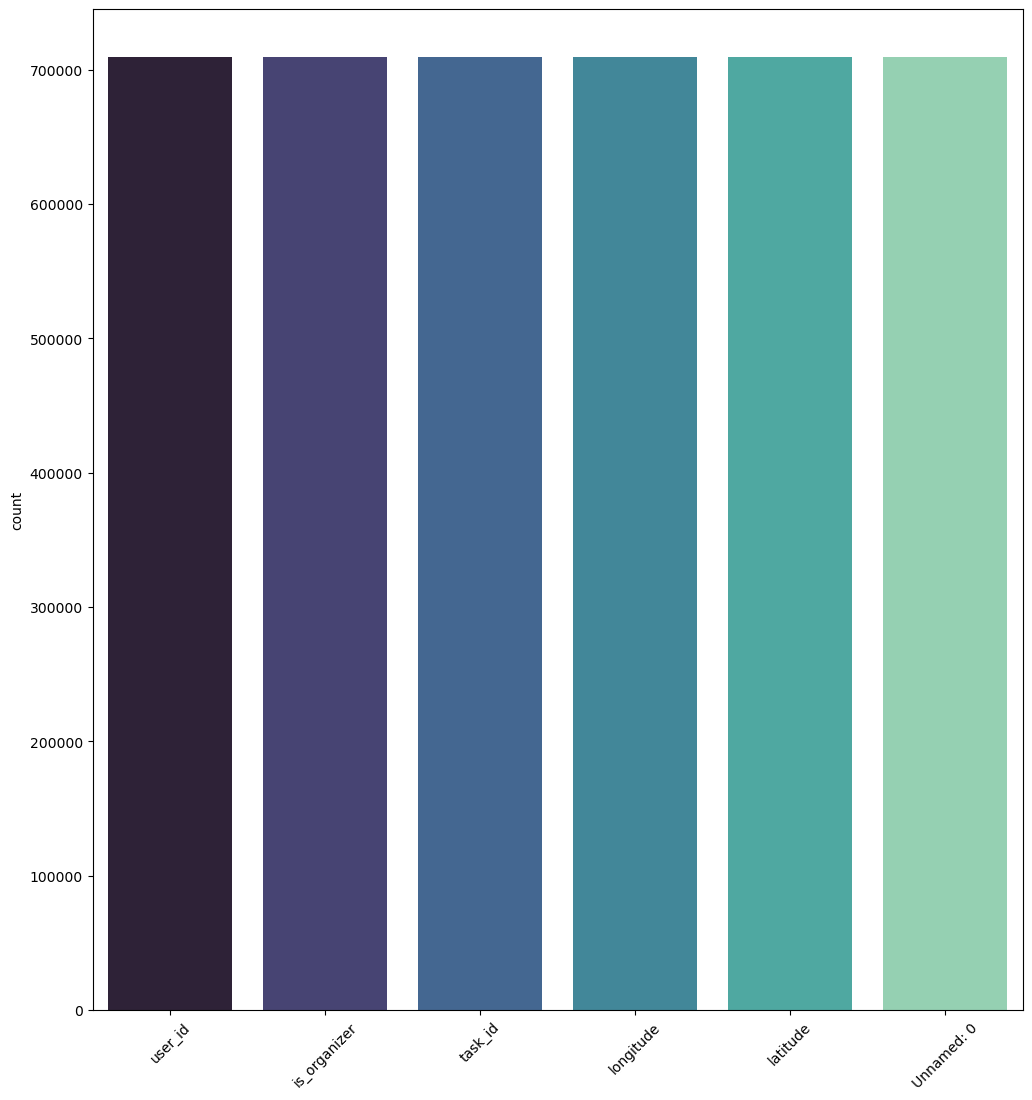

In [24]:
plt.figure(figsize=(12,13))
sns.countplot(combined,palette='mako');
plt.xticks(rotation=45);

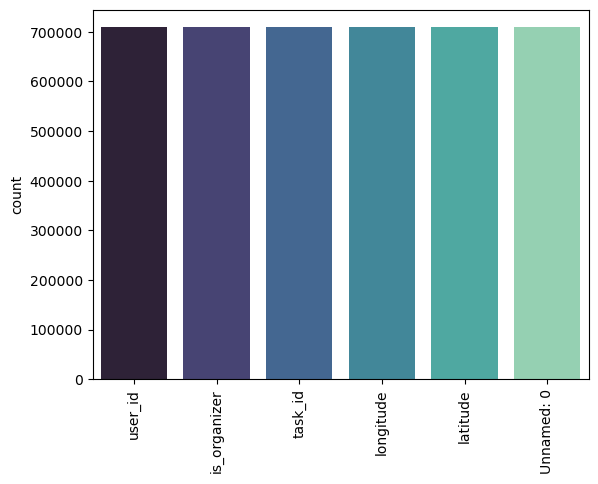

In [25]:
sns.countplot(combined,palette='mako');
plt.xticks(rotation=90);

(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, 'user_id'),
  Text(1, 0, 'is_organizer'),
  Text(2, 0, 'task_id'),
  Text(3, 0, 'longitude'),
  Text(4, 0, 'latitude'),
  Text(5, 0, 'Unnamed: 0')])

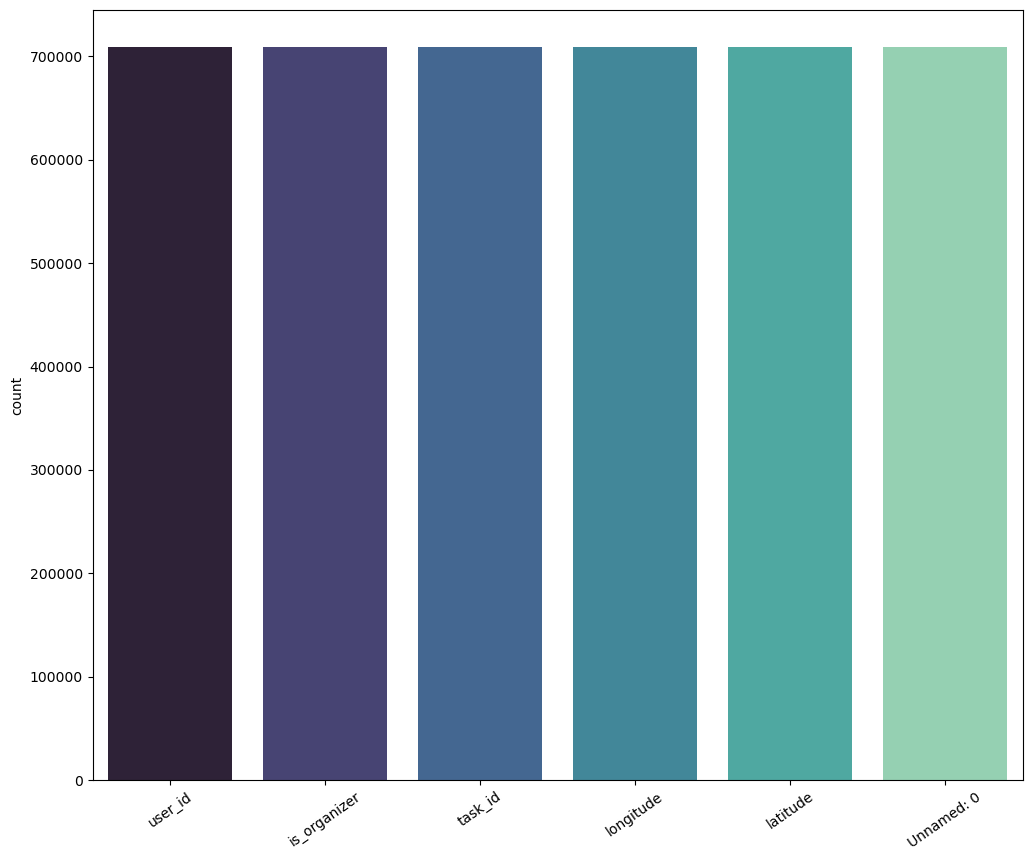

In [26]:
plt.figure(figsize=(12,10))
sns.countplot(combined,palette='mako')
plt.xticks(rotation=35)

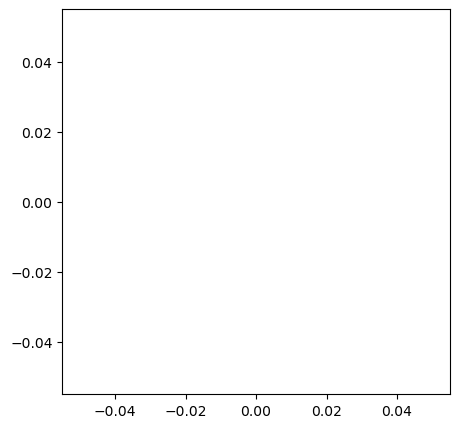

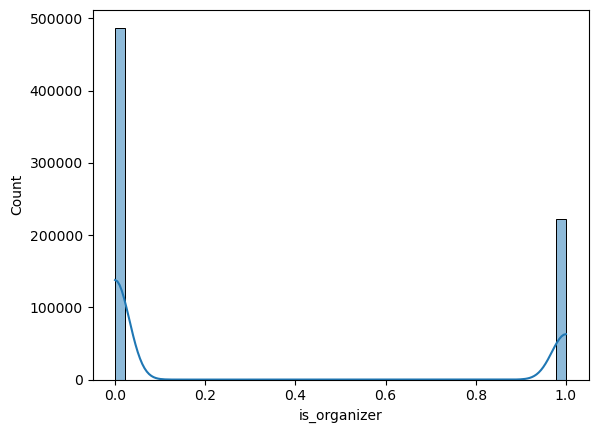

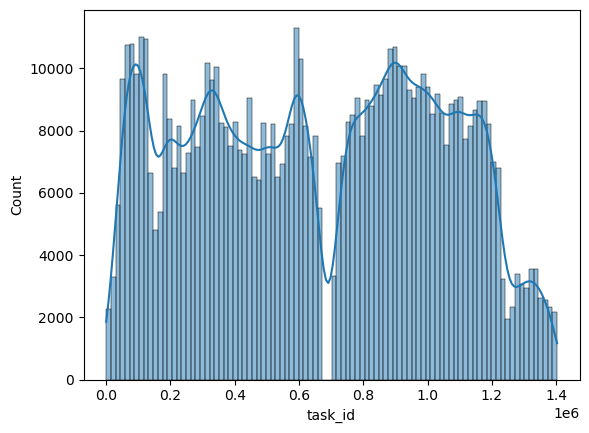

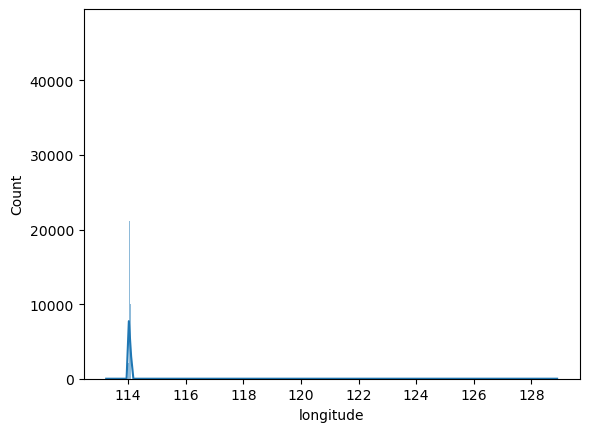

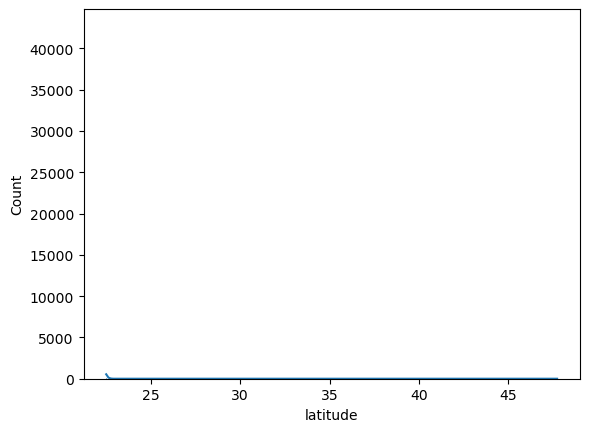

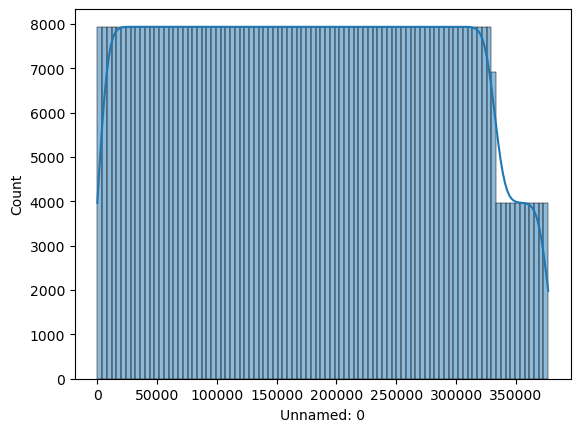

In [27]:
plt.figure(figsize=(5,5))
x=1
for i in num_cols:
    sns.histplot(data=combined,x=i,kde=True)
    print('\n')
    plt.show()

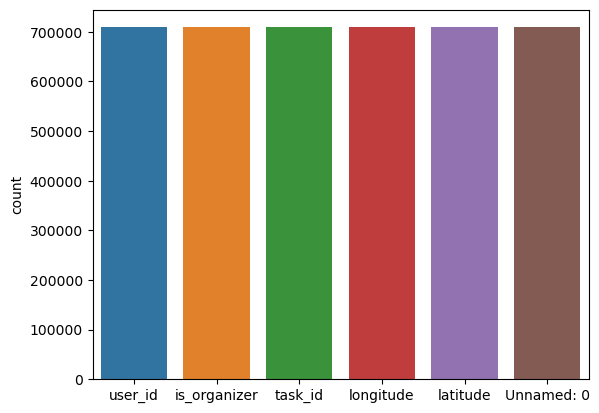

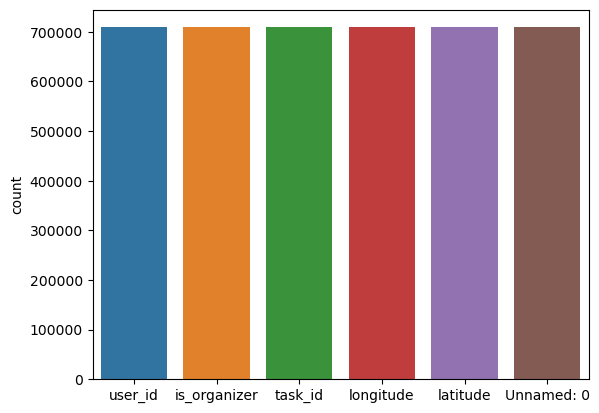

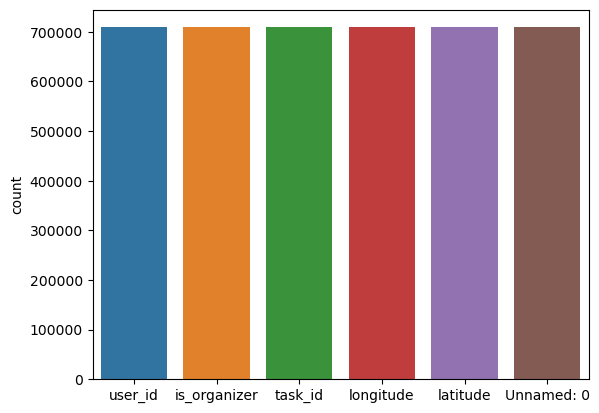

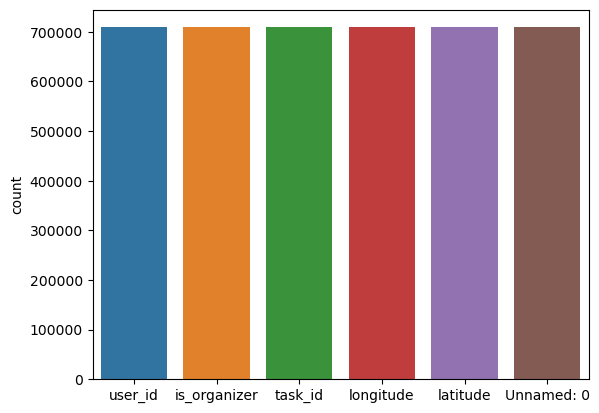

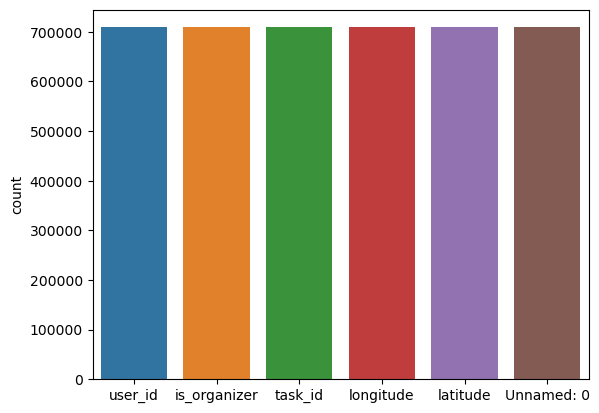

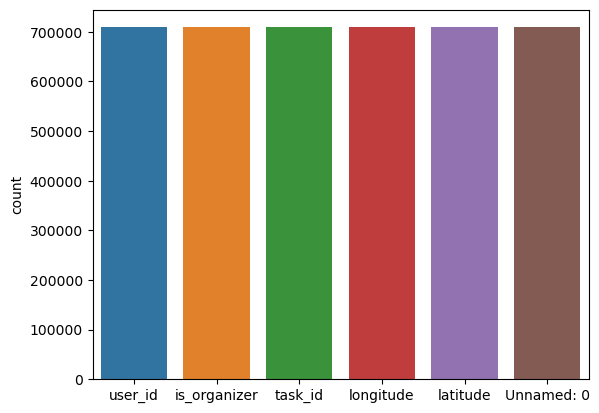

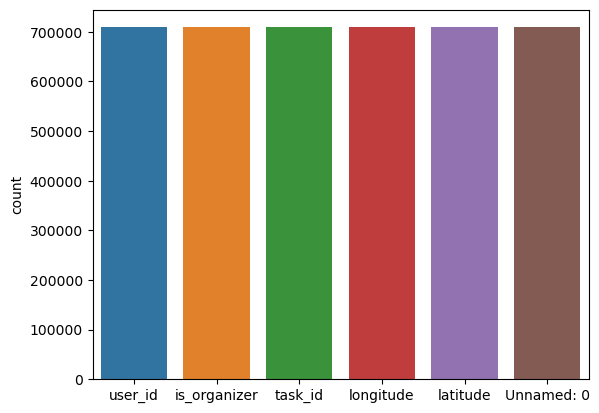

In [28]:
for i in cat_cols:
    x=i
    sns.countplot(data=combined)
    print('\n')
    plt.show()

In [29]:
combined['user_id'].value_counts()

Series([], Name: user_id, dtype: int64)

In [30]:
combined['user_id'].unique()

array([nan])

In [31]:
# Replacing weird values
combined = combined.applymap(lambda x:x if x is np.NaN or not isinstance(x,str)else str(x).strip('_,"')
                            ).replace(['','nan','!@9#%8','#F%$D@*&8'],np.NaN)

In [32]:
combined.head()

,user_id,is_organizer,task_id,task_location,task_district,user_location,longitude,latitude,task_start_time,task_end_time,task_start_date,task_end_date,Unnamed: 0
0,NaN,1,211219,Yuanling(Street),Futian(District),Futian(District)-Yuanling(Street)-Hualin(Commu...,118.746610,32.061234,2020/9/26 1:00,2020/9/26 6:55,2020/9/26,2020/9/26,NaN
1,NaN,0,211095,Fucheng(Street),Longhua(District),Longhua(District)-Fucheng(Street)-Dashuikeng(C...,114.006699,22.730143,2020/9/26 10:30,2020/9/26 17:30,2020/9/26,2020/9/26,NaN
2,NaN,0,211089,Meilin(Street),Futian(District),Futian(District)-Meilin(Street)-Maling(Community),114.066054,22.569335,2020/9/26 16:20,2020/9/26 18:00,2020/9/26,2020/9/26,NaN
3,NaN,0,211089,Meilin(Street),Futian(District),Futian(District)-Meilin(Street)-Maling(Community),114.066054,22.569335,2020/9/26 16:20,2020/9/26 18:00,2020/9/26,2020/9/26,NaN
4,NaN,0,211085,Meilin(Street),Futian(District),Futian(District)-Meilin(Street)-Maling(Community),114.066095,22.569256,2020/9/26 14:00,2020/9/26 16:00,2020/9/26,2020/9/26,NaN


In [33]:
# Treating type of user_id
combined['task_location'].value_counts().head(9).index[1:]

Index(['Nanyuan(Street)', 'Huafu(Street)', 'Shatou(Street)',
       'Xiangmihu(Street)', 'Fubao(Street)', 'Lianhua(Street)',
       'Futian(Street)', 'Yuanling(Street)'],
      dtype='object')

In [34]:
# Rebuild type of user_id
for i in combined['task_location'].value_counts().head(9).index[1:]:
    combined[i]=combined['task_location'].str.contains(i)

/tmp/ipykernel_20/3549045486.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  combined[i]=combined['task_location'].str.contains(i)
/tmp/ipykernel_20/3549045486.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  combined[i]=combined['task_location'].str.contains(i)
/tmp/ipykernel_20/3549045486.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  combined[i]=combined['task_location'].str.contains(i)
/tmp/ipykernel_20/3549045486.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  combined[i]=combined['task_location'].str.contains(i)
/tmp/ipykernel_20/3549045486.py:3: UserWarning: This pattern is interpreted as a regular expression, and

In [35]:
mapping = combined.groupby('user_id')['is_organizer'].mean().to_dict()

In [36]:
combined['is_organizer']=combined['user_id'].map(mapping)

In [37]:
combined.head()

,user_id,is_organizer,task_id,task_location,task_district,user_location,longitude,latitude,task_start_time,task_end_time,task_start_date,task_end_date,Unnamed: 0,Nanyuan(Street),Huafu(Street),Shatou(Street),Xiangmihu(Street),Fubao(Street),Lianhua(Street),Futian(Street),Yuanling(Street)
0,NaN,NaN,211219,Yuanling(Street),Futian(District),Futian(District)-Yuanling(Street)-Hualin(Commu...,118.746610,32.061234,2020/9/26 1:00,2020/9/26 6:55,2020/9/26,2020/9/26,NaN,False,False,False,False,False,False,False,False
1,NaN,NaN,211095,Fucheng(Street),Longhua(District),Longhua(District)-Fucheng(Street)-Dashuikeng(C...,114.006699,22.730143,2020/9/26 10:30,2020/9/26 17:30,2020/9/26,2020/9/26,NaN,False,False,False,False,False,False,False,False
2,NaN,NaN,211089,Meilin(Street),Futian(District),Futian(District)-Meilin(Street)-Maling(Community),114.066054,22.569335,2020/9/26 16:20,2020/9/26 18:00,2020/9/26,2020/9/26,NaN,False,False,False,False,False,False,False,False
3,NaN,NaN,211089,Meilin(Street),Futian(District),Futian(District)-Meilin(Street)-Maling(Community),114.066054,22.569335,2020/9/26 16:20,2020/9/26 18:00,2020/9/26,2020/9/26,NaN,False,False,False,False,False,False,False,False
4,NaN,NaN,211085,Meilin(Street),Futian(District),Futian(District)-Meilin(Street)-Maling(Community),114.066095,22.569256,2020/9/26 14:00,2020/9/26 16:00,2020/9/26,2020/9/26,NaN,False,False,False,False,False,False,False,False


In [38]:
combined.isnull().sum()

user_id              709445
is_organizer         709445
task_id                   0
task_location             0
task_district             0
user_location             0
longitude                 0
latitude                  0
task_start_time           0
task_end_time             0
task_start_date           0
task_end_date             0
Unnamed: 0           332384
Nanyuan(Street)           0
Huafu(Street)             0
Shatou(Street)            0
Xiangmihu(Street)         0
Fubao(Street)             0
Lianhua(Street)           0
Futian(Street)            0
Yuanling(Street)          0
dtype: int64

In [39]:
# Treating null of task_id
combined.groupby('user_id')['task_id'].apply(lambda x:x.fillna(x.mode()[0]))

/tmp/ipykernel_20/1842738117.py:2: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  combined.groupby('user_id')['task_id'].apply(lambda x:x.fillna(x.mode()[0]))


Series([], Name: task_id, dtype: int64)

In [40]:
map1 = combined.groupby(['user_id'])['latitude'].agg(pd.Series.mode).to_dict()

In [41]:
combined['latitude']=combined['user_id'].map(map1)

In [42]:
combined['latitude'].isnull().sum()

709445

In [43]:
combined.head()

,user_id,is_organizer,task_id,task_location,task_district,user_location,longitude,latitude,task_start_time,task_end_time,task_start_date,task_end_date,Unnamed: 0,Nanyuan(Street),Huafu(Street),Shatou(Street),Xiangmihu(Street),Fubao(Street),Lianhua(Street),Futian(Street),Yuanling(Street)
0,NaN,NaN,211219,Yuanling(Street),Futian(District),Futian(District)-Yuanling(Street)-Hualin(Commu...,118.746610,NaN,2020/9/26 1:00,2020/9/26 6:55,2020/9/26,2020/9/26,NaN,False,False,False,False,False,False,False,False
1,NaN,NaN,211095,Fucheng(Street),Longhua(District),Longhua(District)-Fucheng(Street)-Dashuikeng(C...,114.006699,NaN,2020/9/26 10:30,2020/9/26 17:30,2020/9/26,2020/9/26,NaN,False,False,False,False,False,False,False,False
2,NaN,NaN,211089,Meilin(Street),Futian(District),Futian(District)-Meilin(Street)-Maling(Community),114.066054,NaN,2020/9/26 16:20,2020/9/26 18:00,2020/9/26,2020/9/26,NaN,False,False,False,False,False,False,False,False
3,NaN,NaN,211089,Meilin(Street),Futian(District),Futian(District)-Meilin(Street)-Maling(Community),114.066054,NaN,2020/9/26 16:20,2020/9/26 18:00,2020/9/26,2020/9/26,NaN,False,False,False,False,False,False,False,False
4,NaN,NaN,211085,Meilin(Street),Futian(District),Futian(District)-Meilin(Street)-Maling(Community),114.066095,NaN,2020/9/26 14:00,2020/9/26 16:00,2020/9/26,2020/9/26,NaN,False,False,False,False,False,False,False,False


In [44]:
# Treating null of longitude
combined['longitude'].isnull().sum()

0

In [45]:
map2 = combined.groupby(['user_id'])['longitude'].mean().to_dict()

In [46]:
combined['longitude']=combined['user_id'].map(map2)

In [47]:
combined['longitude'].isnull().sum()

709445

In [48]:
combined.head()

,user_id,is_organizer,task_id,task_location,task_district,user_location,longitude,latitude,task_start_time,task_end_time,task_start_date,task_end_date,Unnamed: 0,Nanyuan(Street),Huafu(Street),Shatou(Street),Xiangmihu(Street),Fubao(Street),Lianhua(Street),Futian(Street),Yuanling(Street)
0,NaN,NaN,211219,Yuanling(Street),Futian(District),Futian(District)-Yuanling(Street)-Hualin(Commu...,NaN,NaN,2020/9/26 1:00,2020/9/26 6:55,2020/9/26,2020/9/26,NaN,False,False,False,False,False,False,False,False
1,NaN,NaN,211095,Fucheng(Street),Longhua(District),Longhua(District)-Fucheng(Street)-Dashuikeng(C...,NaN,NaN,2020/9/26 10:30,2020/9/26 17:30,2020/9/26,2020/9/26,NaN,False,False,False,False,False,False,False,False
2,NaN,NaN,211089,Meilin(Street),Futian(District),Futian(District)-Meilin(Street)-Maling(Community),NaN,NaN,2020/9/26 16:20,2020/9/26 18:00,2020/9/26,2020/9/26,NaN,False,False,False,False,False,False,False,False
3,NaN,NaN,211089,Meilin(Street),Futian(District),Futian(District)-Meilin(Street)-Maling(Community),NaN,NaN,2020/9/26 16:20,2020/9/26 18:00,2020/9/26,2020/9/26,NaN,False,False,False,False,False,False,False,False
4,NaN,NaN,211085,Meilin(Street),Futian(District),Futian(District)-Meilin(Street)-Maling(Community),NaN,NaN,2020/9/26 14:00,2020/9/26 16:00,2020/9/26,2020/9/26,NaN,False,False,False,False,False,False,False,False


In [49]:
# Treating null of task_start_time with help of user_id
combined['task_id']=combined['task_id'].astype(float)

In [50]:
map3 = combined.groupby('user_id')['task_id'].median().to_dict()

In [51]:
combined['task_id']=combined['user_id'].map(map3)

In [52]:
combined['task_id']=round(combined['task_id'],0)

In [53]:
combined.head()

,user_id,is_organizer,task_id,task_location,task_district,user_location,longitude,latitude,task_start_time,task_end_time,task_start_date,task_end_date,Unnamed: 0,Nanyuan(Street),Huafu(Street),Shatou(Street),Xiangmihu(Street),Fubao(Street),Lianhua(Street),Futian(Street),Yuanling(Street)
0,NaN,NaN,NaN,Yuanling(Street),Futian(District),Futian(District)-Yuanling(Street)-Hualin(Commu...,NaN,NaN,2020/9/26 1:00,2020/9/26 6:55,2020/9/26,2020/9/26,NaN,False,False,False,False,False,False,False,False
1,NaN,NaN,NaN,Fucheng(Street),Longhua(District),Longhua(District)-Fucheng(Street)-Dashuikeng(C...,NaN,NaN,2020/9/26 10:30,2020/9/26 17:30,2020/9/26,2020/9/26,NaN,False,False,False,False,False,False,False,False
2,NaN,NaN,NaN,Meilin(Street),Futian(District),Futian(District)-Meilin(Street)-Maling(Community),NaN,NaN,2020/9/26 16:20,2020/9/26 18:00,2020/9/26,2020/9/26,NaN,False,False,False,False,False,False,False,False
3,NaN,NaN,NaN,Meilin(Street),Futian(District),Futian(District)-Meilin(Street)-Maling(Community),NaN,NaN,2020/9/26 16:20,2020/9/26 18:00,2020/9/26,2020/9/26,NaN,False,False,False,False,False,False,False,False
4,NaN,NaN,NaN,Meilin(Street),Futian(District),Futian(District)-Meilin(Street)-Maling(Community),NaN,NaN,2020/9/26 14:00,2020/9/26 16:00,2020/9/26,2020/9/26,NaN,False,False,False,False,False,False,False,False


In [54]:
combined['task_location']=combined['user_location'].str.split('_').str[0]

In [55]:
combined['task_district']=combined['task_district'].str.split('_').str[2]

In [56]:
combined.head()

,user_id,is_organizer,task_id,task_location,task_district,user_location,longitude,latitude,task_start_time,task_end_time,task_start_date,task_end_date,Unnamed: 0,Nanyuan(Street),Huafu(Street),Shatou(Street),Xiangmihu(Street),Fubao(Street),Lianhua(Street),Futian(Street),Yuanling(Street)
0,NaN,NaN,NaN,Futian(District)-Yuanling(Street)-Hualin(Commu...,NaN,Futian(District)-Yuanling(Street)-Hualin(Commu...,NaN,NaN,2020/9/26 1:00,2020/9/26 6:55,2020/9/26,2020/9/26,NaN,False,False,False,False,False,False,False,False
1,NaN,NaN,NaN,Longhua(District)-Fucheng(Street)-Dashuikeng(C...,NaN,Longhua(District)-Fucheng(Street)-Dashuikeng(C...,NaN,NaN,2020/9/26 10:30,2020/9/26 17:30,2020/9/26,2020/9/26,NaN,False,False,False,False,False,False,False,False
2,NaN,NaN,NaN,Futian(District)-Meilin(Street)-Maling(Community),NaN,Futian(District)-Meilin(Street)-Maling(Community),NaN,NaN,2020/9/26 16:20,2020/9/26 18:00,2020/9/26,2020/9/26,NaN,False,False,False,False,False,False,False,False
3,NaN,NaN,NaN,Futian(District)-Meilin(Street)-Maling(Community),NaN,Futian(District)-Meilin(Street)-Maling(Community),NaN,NaN,2020/9/26 16:20,2020/9/26 18:00,2020/9/26,2020/9/26,NaN,False,False,False,False,False,False,False,False
4,NaN,NaN,NaN,Futian(District)-Meilin(Street)-Maling(Community),NaN,Futian(District)-Meilin(Street)-Maling(Community),NaN,NaN,2020/9/26 14:00,2020/9/26 16:00,2020/9/26,2020/9/26,NaN,False,False,False,False,False,False,False,False


In [57]:
combined.drop('task_district',inplace=True,axis=1)

In [58]:
combined.isnull().sum()

user_id              709445
is_organizer         709445
task_id              709445
task_location             0
user_location             0
longitude            709445
latitude             709445
task_start_time           0
task_end_time             0
task_start_date           0
task_end_date             0
Unnamed: 0           332384
Nanyuan(Street)           0
Huafu(Street)             0
Shatou(Street)            0
Xiangmihu(Street)         0
Fubao(Street)             0
Lianhua(Street)           0
Futian(Street)            0
Yuanling(Street)          0
dtype: int64

In [59]:
cat_cols.shape,num_cols.shape

((709445, 7), (709445, 6))

In [60]:
combined.shape

(709445, 20)

In [61]:
combined['Nanyuan(Street)']=combined['Nanyuan(Street)'].map({True:1,False:0,np.nan:0})

In [62]:
combined['Huafu(Street)']=combined['Huafu(Street)'].map({True:1,False:0,np.nan:0})
combined['Shatou(Street)']=combined['Shatou(Street)'].map({True:1,False:0,np.nan:0})
combined['Xiangmihu(Street)']=combined['Xiangmihu(Street)'].map({True:1,False:0,np.nan:0})
combined['Fubao(Street)']=combined['Fubao(Street)'].map({True:1,False:0,np.nan:0})
combined['Lianhua(Street)']=combined['Lianhua(Street)'].map({True:1,False:0,np.nan:0})
combined['Futian(Street)']=combined['Futian(Street)'].map({True:1,False:0,np.nan:0})
combined['Yuanling(Street)']=combined['Yuanling(Street)'].map({True:1,False:0,np.nan:0})


In [63]:
combined['Yuanling(Street)'].unique()

array([0])

In [64]:
cat_cols

,task_location,task_district,user_location,task_start_time,task_end_time,task_start_date,task_end_date
0,Yuanling(Street),Futian(District),Futian(District)-Yuanling(Street)-Hualin(Commu...,2020/9/26 1:00,2020/9/26 6:55,2020/9/26,2020/9/26
1,Fucheng(Street),Longhua(District),Longhua(District)-Fucheng(Street)-Dashuikeng(C...,2020/9/26 10:30,2020/9/26 17:30,2020/9/26,2020/9/26
2,Meilin(Street),Futian(District),Futian(District)-Meilin(Street)-Maling(Community),2020/9/26 16:20,2020/9/26 18:00,2020/9/26,2020/9/26
3,Meilin(Street),Futian(District),Futian(District)-Meilin(Street)-Maling(Community),2020/9/26 16:20,2020/9/26 18:00,2020/9/26,2020/9/26
4,Meilin(Street),Futian(District),Futian(District)-Meilin(Street)-Maling(Community),2020/9/26 14:00,2020/9/26 16:00,2020/9/26,2020/9/26
...,...,...,...,...,...,...,...
377056,Xiangmihu(Street),Futian(District),Futian(District)-Xiangmihu(Street)-Donghai(Com...,2021-08-03 08:55:00,2021-08-03 09:55:00,2021-08-03,2021-08-03
377057,Xiangmihu(Street),Futian(District),Futian(District)-Xiangmihu(Street)-Donghai(Com...,2021-08-03 09:45:00,2021-08-03 10:45:00,2021-08-03,2021-08-03
377058,Xiangmihu(Street),Futian(District),Futian(District)-Xiangmihu(Street)-Donghai(Com...,2021-08-05 08:25:00,2021-08-05 09:25:00,2021-08-05,2021-08-05
377059,Xiangmihu(Street),Futian(District),Futian(District)-Xiangmihu(Street)-Donghai(Com...,2021-08-05 08:40:00,2021-08-05 09:40:00,2021-08-05,2021-08-05


In [65]:
combined['user_id'].value_counts(normalize=True)*100

Series([], Name: user_id, dtype: float64)

In [66]:
train.shape[0]

332384

In [67]:
new_train=combined.iloc[0:train.shape[0],:]

In [68]:
new_test=combined.iloc[train.shape[0]:,:]

In [69]:
train.shape,new_train.shape,test.shape,new_test.shape

((332384, 12), (332384, 20), (377061, 13), (377061, 20))

In [70]:
import scipy.stats as stats

In [71]:
sig_num=[]
for i in num_cols:
    zero=new_train.loc[new_train['user_id']==0,i]
    one=new_train.loc[new_train['user_id']==1,i]
    two=new_train.loc[new_train['user_id']==2,i]
    teststat,pval=stats.f_oneway(zero,one,two)
    if pval<0.05:
        sig_num.append(i)
        print(i)

/opt/conda/lib/python3.10/site-packages/scipy/stats/_stats_py.py:3861: DegenerateDataWarning: at least one input has length 0
  warnings.warn(stats.DegenerateDataWarning('at least one input '


In [72]:
train_new = new_train.loc[sig_num]

In [73]:
test_new=new_test.loc[sig_num]

In [74]:
# Checking for multicolinearity


In [75]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [76]:
train_new

,user_id,is_organizer,task_id,task_location,user_location,longitude,latitude,task_start_time,task_end_time,task_start_date,task_end_date,Unnamed: 0,Nanyuan(Street),Huafu(Street),Shatou(Street),Xiangmihu(Street),Fubao(Street),Lianhua(Street),Futian(Street),Yuanling(Street)


In [77]:
test_new


,user_id,is_organizer,task_id,task_location,user_location,longitude,latitude,task_start_time,task_end_time,task_start_date,task_end_date,Unnamed: 0,Nanyuan(Street),Huafu(Street),Shatou(Street),Xiangmihu(Street),Fubao(Street),Lianhua(Street),Futian(Street),Yuanling(Street)


In [78]:
# Scaling the col

In [79]:
scaling=[]

In [80]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [81]:
for i in scaling:
    train_new.loc[:,i]=scaler.fit_transform(pd.DataFrame(train_new.loc[:,i]))
    test_new.loc[:,i]=scaler.transform(pd.DataFrame(test_new.loc[:,i]))

In [82]:
train_new

,user_id,is_organizer,task_id,task_location,user_location,longitude,latitude,task_start_time,task_end_time,task_start_date,task_end_date,Unnamed: 0,Nanyuan(Street),Huafu(Street),Shatou(Street),Xiangmihu(Street),Fubao(Street),Lianhua(Street),Futian(Street),Yuanling(Street)


In [83]:
# Encoding

In [84]:
train_encoded=pd.get_dummies(train_new,drop_first=True)

In [85]:
test_encoded=pd.get_dummies(test_new,drop_first=True)

In [86]:
train_encoded

,user_id,is_organizer,task_id,longitude,latitude,Unnamed: 0,Nanyuan(Street),Huafu(Street),Shatou(Street),Xiangmihu(Street),Fubao(Street),Lianhua(Street),Futian(Street),Yuanling(Street)


In [87]:
x=train_encoded.drop('user_id',axis=1)
y=train_encoded['user_id']

In [88]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [89]:
lr=LogisticRegression()
dt=DecisionTreeClassifier()